In [309]:
# Colab 환경일 때만 실행
# from google.colab import drive
# drive.mount('/content/drive')

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix



In [310]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [311]:
FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt"

In [312]:
df = pd.read_csv(FILE_PATH, header=None, on_bad_lines='skip')

In [313]:
df

,0,1,2,3,4,5
0,33,Jogging,49105962326000,-0.694638,12.680544,0.50395286;
1,33,Jogging,49106062271000,5.012288,11.264028,0.95342433;
2,33,Jogging,49106112167000,4.903325,10.882658,-0.08172209;
3,33,Jogging,49106222305000,-0.612916,18.496431,3.0237172;
4,33,Jogging,49106332290000,-1.184970,12.108489,7.205164;
...,...,...,...,...,...,...
1086461,19,Sitting,131623331483000,9.000000,-1.570000,1.69;
1086462,19,Sitting,131623371431000,9.040000,-1.460000,1.73;
1086463,19,Sitting,131623411592000,9.080000,-1.380000,1.69;
1086464,19,Sitting,131623491487000,9.000000,-1.460000,1.73;


In [314]:
df.columns = ['user', 'activity', 'timestamp', 'x', 'y', 'z']

In [315]:
# z 끝에 붙는 세미콜론 제거 후 숫자형 변환
df['z'] = df['z'].astype(str).str.replace(';','', regex=False)
df['z'] = pd.to_numeric(df['z'], errors='coerce')  # 숫자 변환

# NaN
print(f"변환 전: {len(df)}")
df = df.dropna()
print(f"NaN 제거 후: {len(df)}")


변환 전: 1086466
NaN 제거 후: 1086465


In [316]:
df

,user,activity,timestamp,x,y,z
0,33,Jogging,49105962326000,-0.694638,12.680544,0.503953
1,33,Jogging,49106062271000,5.012288,11.264028,0.953424
2,33,Jogging,49106112167000,4.903325,10.882658,-0.081722
3,33,Jogging,49106222305000,-0.612916,18.496431,3.023717
4,33,Jogging,49106332290000,-1.184970,12.108489,7.205164
...,...,...,...,...,...,...
1086461,19,Sitting,131623331483000,9.000000,-1.570000,1.690000
1086462,19,Sitting,131623371431000,9.040000,-1.460000,1.730000
1086463,19,Sitting,131623411592000,9.080000,-1.380000,1.690000
1086464,19,Sitting,131623491487000,9.000000,-1.460000,1.730000


In [317]:
df = df.drop(columns=["timestamp"])

In [318]:
df.isnull().sum()

,0
user,0
activity,0
x,0
y,0
z,0


In [319]:
df['activity'].value_counts()

,count
activity,
Walking,418393
Jogging,336445
Upstairs,122869
Downstairs,100425
Sitting,59939
Standing,48394


In [320]:
print(df.shape)
df


(1086465, 5)


,user,activity,x,y,z
0,33,Jogging,-0.694638,12.680544,0.503953
1,33,Jogging,5.012288,11.264028,0.953424
2,33,Jogging,4.903325,10.882658,-0.081722
3,33,Jogging,-0.612916,18.496431,3.023717
4,33,Jogging,-1.184970,12.108489,7.205164
...,...,...,...,...,...
1086461,19,Sitting,9.000000,-1.570000,1.690000
1086462,19,Sitting,9.040000,-1.460000,1.730000
1086463,19,Sitting,9.080000,-1.380000,1.690000
1086464,19,Sitting,9.000000,-1.460000,1.730000


In [321]:
# 라벨 인코딩
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['activity'])
num_classes = len(le.classes_)

print("샘플 수:", len(df), "라벨:", list(le.classes_))


샘플 수: 1086465 라벨: ['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']


In [322]:
# ===============================
# 1. 윈도우 생성 함수 (Time-windowing)
# ===============================
import numpy as np

def create_windows(df, window_size=128, step=64):
    """
    user 단위로 데이터를 잘라서
    window_size 길이의 구간을 step 간격으로 슬라이딩하면서
    [x, y, z] 시계열과 그 윈도우의 대표 라벨(label_id, 다수결)을 만든다.
    """
    X_list = []
    y_list = []

    for user, user_df in df.groupby("user"):
        # 시간 순서대로 정렬 (안전하게)
        user_df = user_df.reset_index(drop=True)

        data = user_df[["x", "y", "z"]].values   # (len_user, 3)
        labels = user_df["label_id"].values      # (len_user,)

        for start in range(0, len(user_df) - window_size + 1, step):
            end = start + window_size
            window_data = data[start:end]        # (window_size, 3)
            window_labels = labels[start:end]    # (window_size,)

            # 윈도우 안 라벨의 다수결
            majority_label = np.bincount(window_labels).argmax()

            X_list.append(window_data)
            y_list.append(majority_label)

    X = np.array(X_list)        # (num_windows, window_size, 3)
    y = np.array(y_list)        # (num_windows,)

    print("생성된 윈도우 개수:", X.shape[0])
    print("각 윈도우 길이:", X.shape[1])
    print("특성 수:", X.shape[2])
    return X, y

WINDOW_SIZE = 128
STEP = 64
X, y = create_windows(df, window_size=WINDOW_SIZE, step=STEP)
num_features = X.shape[2]

생성된 윈도우 개수: 16922
각 윈도우 길이: 128
특성 수: 3


In [323]:
# ===============================
# 2. 표준화 (StandardScaler 사용)
# ===============================
from sklearn.preprocessing import StandardScaler

X_2d = X.reshape(-1, num_features)  # (num_windows*window_size, num_features)

scaler = StandardScaler()
X_2d_scaled = scaler.fit_transform(X_2d)
X_2d_scaled = np.clip(X_2d_scaled, -10, 10)
X_scaled = X_2d_scaled.reshape(X.shape[0], X.shape[1], num_features)

print("스케일링 후 X_scaled shape:", X_scaled.shape)


스케일링 후 X_scaled shape: (16922, 128, 3)


In [324]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=RANDOM_SEED,stratify=y)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train 라벨 분포:", np.bincount(y_train))
print("Test 라벨 분포:", np.bincount(y_test))


Train shape: (13537, 128, 3) Test shape: (3385, 128, 3)
Train 라벨 분포: [1250 4200  745  591 1535 5216]
Test 라벨 분포: [ 313 1050  186  148  384 1304]


In [325]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense

input_shape = (WINDOW_SIZE, num_features)

model = Sequential([
    # Conv 블록 1개만 사용
    Conv1D(32, kernel_size=5, activation='relu', padding='same', input_shape=input_shape),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_27 (Conv1D)              │ (None, 128, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_19 (MaxPooling1D) │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,038 (515.77 KB)

 Trainable params: 132,038 (515.77 KB)

 Non-trainable params: 0 (0.00 B)

In [326]:
EPOCHS = 20
BATCH_SIZE = 128

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,

    verbose=1
)


Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.5408 - loss: 1.1916 - val_accuracy: 0.7589 - val_loss: 0.6611
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7680 - loss: 0.6585 - val_accuracy: 0.8098 - val_loss: 0.5215
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8056 - loss: 0.5357 - val_accuracy: 0.8316 - val_loss: 0.4482
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8269 - loss: 0.4570 - val_accuracy: 0.8490 - val_loss: 0.3982
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8475 - loss: 0.4041 - val_accuracy: 0.8641 - val_loss: 0.3543
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8588 - loss: 0.3720 - val_accuracy: 0.8737 - val_loss: 0.3275
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8765 - loss: 0.3349 - val_accuracy: 0.8818 - val_loss: 0.3078
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8765 - loss: 0.3155 - val_accuracy: 0.8815 - val_loss

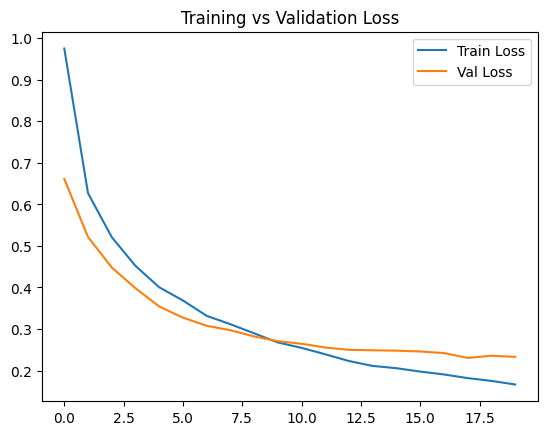

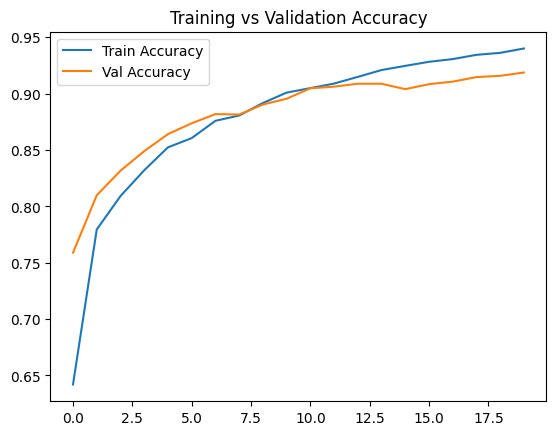

In [327]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

In [328]:
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\n분류 리포트:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\n혼동 행렬:")
print(confusion_matrix(y_test, y_pred))


Test Loss: 0.2543, Test Accuracy: 0.9146
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

분류 리포트:
              precision    recall  f1-score   support

  Downstairs       0.75      0.66      0.70       313
     Jogging       0.96      0.98      0.97      1050
     Sitting       1.00      0.96      0.98       186
    Standing       0.95      0.97      0.96       148
    Upstairs       0.76      0.67      0.71       384
     Walking       0.93      0.98      0.96      1304

    accuracy                           0.91      3385
   macro avg       0.89      0.87      0.88      3385
weighted avg       0.91      0.91      0.91      3385


혼동 행렬:
[[ 206    6    0    0   66   35]
 [   2 1030    0    0    4   14]
 [   0    0  178    7    1    0]
 [   2    0    0  144    2    0]
 [  56   25    0    1  257   45]
 [   7    7    0    0    9 1281]]
